In [3]:
import matplotlib as pyplot
import pandas as pd
import numpy as np
import seaborn as sns

In [9]:
df=pd.read_csv('Healthcare Analytics for Doctor Visits.csv')
df.head(15)

,Unnamed: 0,visits,gender,age,income,illness,reduced,health,private,freepoor,freerepat,nchronic,lchronic
0,1,1,female,0.19,0.55,1,4,1,yes,no,no,no,no
1,2,1,female,0.19,0.45,1,2,1,yes,no,no,no,no
2,3,1,male,0.19,0.90,3,0,0,no,no,no,no,no
3,4,1,male,0.19,0.15,1,0,0,no,no,no,no,no
4,5,1,male,0.19,0.45,2,5,1,no,no,no,yes,no
5,6,1,female,0.19,0.35,5,1,9,no,no,no,yes,no
6,7,1,female,0.19,0.55,4,0,2,no,no,no,no,no
7,8,1,female,0.19,0.15,3,0,6,no,no,no,no,no
8,9,1,female,0.19,0.65,2,0,5,yes,no,no,no,no
9,10,1,male,0.19,0.15,1,0,0,yes,no,no,no,no


In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5190 entries, 0 to 5189
Data columns (total 13 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  5190 non-null   int64  
 1   visits      5190 non-null   int64  
 2   gender      5190 non-null   str    
 3   age         5190 non-null   float64
 4   income      5190 non-null   float64
 5   illness     5190 non-null   int64  
 6   reduced     5190 non-null   int64  
 7   health      5190 non-null   int64  
 8   private     5190 non-null   str    
 9   freepoor    5190 non-null   str    
 10  freerepat   5190 non-null   str    
 11  nchronic    5190 non-null   str    
 12  lchronic    5190 non-null   str    
dtypes: float64(2), int64(5), str(6)
memory usage: 609.6 KB


In [13]:
df["illness"].value_counts().sort_index()

illness
0    1554
1    1638
2     946
3     542
4     274
5     236
Name: count, dtype: int64

In [15]:
df["gender"].value_counts().sort_index()

gender
female    2702
male      2488
Name: count, dtype: int64

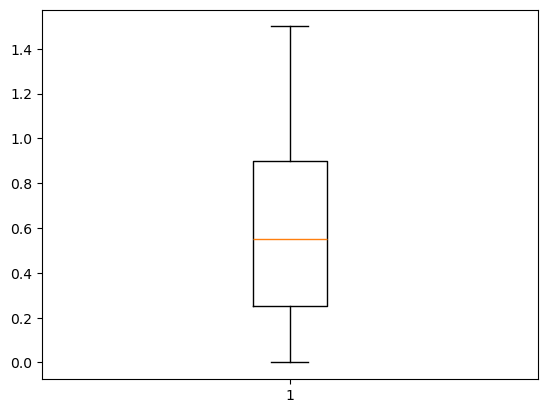

In [20]:
y=list(df.income)
plt.boxplot(y)
plt.show()

In [24]:
df.groupby(['gender', 'reduced'])['visits'].mean()

gender  reduced
female  0          0.229322
        1          0.400000
        2          0.672727
        3          1.333333
        4          0.851852
        5          1.444444
        6          1.363636
        7          1.384615
        8          1.090909
        9          0.500000
        10         2.142857
        12         2.000000
        13         4.000000
        14         1.543103
male    0          0.136007
        1          0.304878
        2          0.471698
        3          0.724138
        4          0.722222
        5          1.136364
        6          0.833333
        7          0.750000
        8          1.333333
        9          2.200000
        10         1.800000
        11         5.000000
        12         2.000000
        13         4.000000
        14         1.555556
Name: visits, dtype: float64

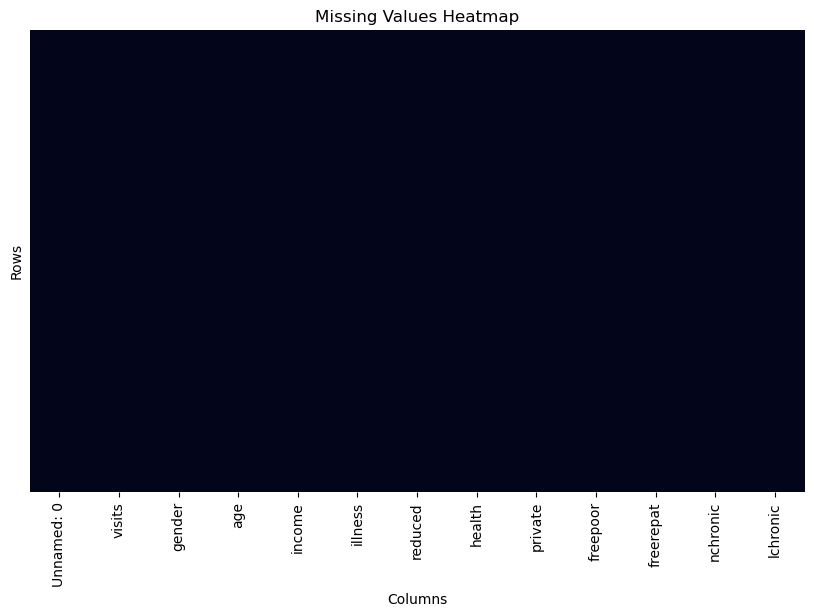

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.heatmap(df.isnull(), cbar=False, yticklabels=False)

plt.title("Missing Values Heatmap")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

            Unnamed: 0    visits       age    income   illness   reduced  \
Unnamed: 0    1.000000 -0.521645 -0.016322  0.074632 -0.290047 -0.245314   
visits       -0.521645  1.000000  0.124537 -0.076840  0.223552  0.418954   
age          -0.016322  0.124537  1.000000 -0.271073  0.204984  0.094745   
income        0.074632 -0.076840 -0.271073  1.000000 -0.148812 -0.047545   
illness      -0.290047  0.223552  0.204984 -0.148812  1.000000  0.218116   
reduced      -0.245314  0.418954  0.094745 -0.047545  0.218116  1.000000   
health       -0.194966  0.193272  0.018616 -0.085790  0.360110  0.280208   

              health  
Unnamed: 0 -0.194966  
visits      0.193272  
age         0.018616  
income     -0.085790  
illness     0.360110  
reduced     0.280208  
health      1.000000  


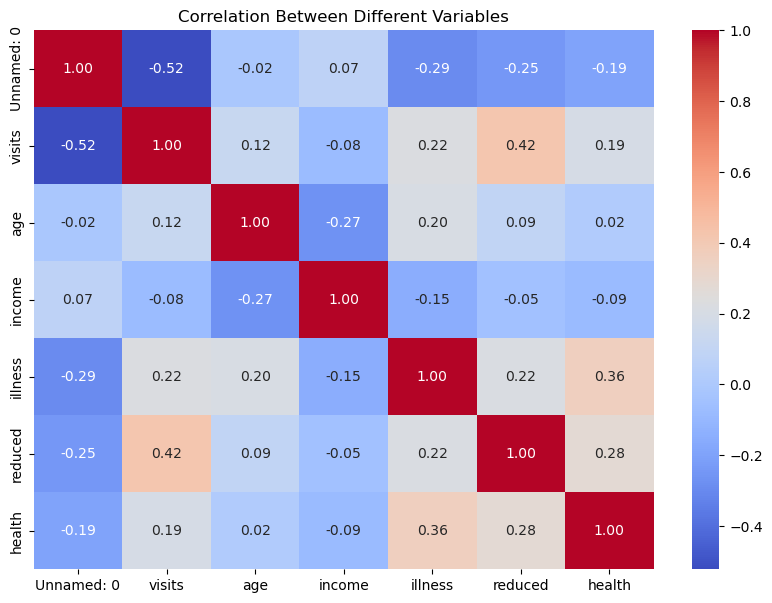

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation between numerical variables
correlation = df.corr(numeric_only=True)

print(correlation)

# Visualize correlation using heatmap
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Different Variables")
plt.show()

Correlation between Income and Doctor Visits: -0.07683982934758704


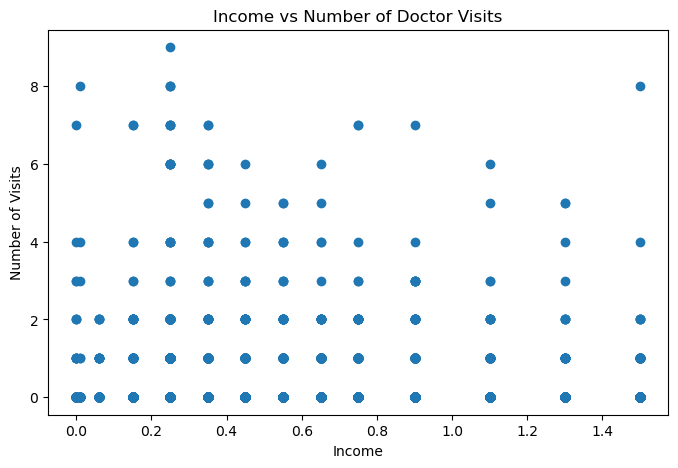

In [30]:
import matplotlib.pyplot as plt

# Correlation between income and visits
correlation = df["income"].corr(df["visits"])

print("Correlation between Income and Doctor Visits:", correlation)

# Visualization
plt.figure(figsize=(8, 5))

plt.scatter(df["income"], df["visits"])

plt.title("Income vs Number of Doctor Visits")
plt.xlabel("Income")
plt.ylabel("Number of Visits")

plt.show()

<Axes: xlabel='gender', ylabel='Count'>

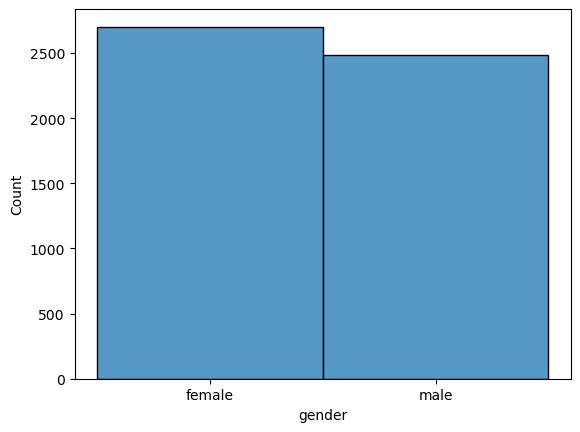

In [34]:
sns.histplot(df.gender,bins=2)

Low Income Healthcare: 4.28 %
Old Age Healthcare: 21.02 %
Private Health Insurance: 44.28 %


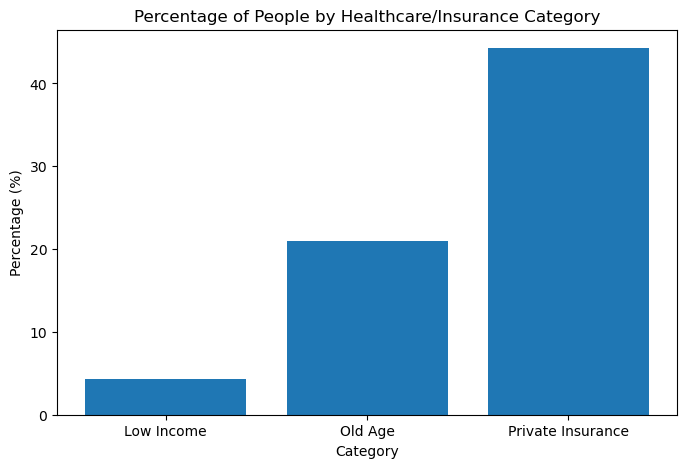

In [38]:
import matplotlib.pyplot as plt

# Calculate percentage
low_income = (df["freepoor"] == "yes").mean() * 100
old_age = (df["freerepat"] == "yes").mean() * 100
private_insurance = (df["private"] == "yes").mean() * 100

# Print percentages
print("Low Income Healthcare:", round(low_income, 2), "%")
print("Old Age Healthcare:", round(old_age, 2), "%")
print("Private Health Insurance:", round(private_insurance, 2), "%")

# Visualization
categories = ["Low Income", "Old Age", "Private Insurance"]
percentages = [low_income, old_age, private_insurance]

plt.figure(figsize=(8, 5))
plt.bar(categories, percentages)

plt.title("Percentage of People by Healthcare/Insurance Category")
plt.xlabel("Category")
plt.ylabel("Percentage (%)")

plt.show()

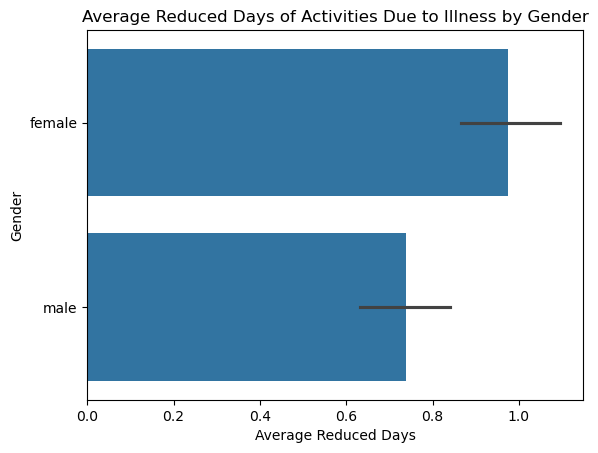

In [43]:
sns.barplot(data=df, y='gender', x='reduced', estimator='mean')
plt.title('Average Reduced Days of Activities Due to Illness by Gender')
plt.xlabel('Average Reduced Days')
plt.ylabel('Gender')
plt.show()